# Logistic Regression Model

For this notebook, I used the final 18-feature files and trained a logistic regression model for the Chagas ECG project.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

/Users/rmhsh8/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load the final processed data

These are the final filtered CSVs from Khushleen's feature selection work.

In [2]:
data_dir = Path("processed_data")

train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"
test_path = data_dir / "test_final.csv"

In [3]:
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

train.head()

Train shape: (7746, 19)
Validation shape: (2584, 19)


,age,is_male,P_wave_duration_mean,P_wave_duration_std,PR_interval_mean,PR_interval_std,PR_segment_mean,PR_segment_std,QRS_duration_mean,QRS_duration_std,QT_interval_mean,QT_interval_std,ST_segment_mean,ST_segment_std,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,target
0,-0.080067,-0.787935,-0.841006,-0.055135,1.089002,0.918455,1.332512,0.813291,-0.763211,-0.812053,0.201465,-0.630556,0.077558,-0.351457,0.946333,0.328705,-0.010365,1.386769,0
1,-1.191728,-0.787935,0.873540,-0.534451,0.366340,-0.757167,0.026520,-0.935958,-0.944048,-0.864915,0.020317,-0.806844,0.295670,-0.639444,0.672048,-0.043469,-0.208611,0.549509,0
2,-0.858230,1.269141,0.772142,-1.105336,0.294966,-0.833143,-0.003735,-0.984452,-0.775267,-0.795702,-0.018980,-0.771288,-0.039706,-0.865024,0.564292,-0.270677,-0.372043,-0.329613,0
3,0.753680,-0.787935,0.142246,-0.352941,-0.287922,-0.245758,-0.323090,-0.066711,0.534796,0.102527,0.171114,-0.353349,0.253455,0.068981,-0.308943,-0.508589,-0.483267,-0.706380,0
4,1.198344,1.269141,-0.687373,-0.249492,0.223592,-0.501063,0.461290,-0.524668,-0.413593,-0.444668,-1.675512,1.929814,-1.138082,2.036125,-0.123381,-0.196938,-0.380236,0.047154,0


## Check columns and target balance

In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

Train columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Validation columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']


In [5]:
print("Train target counts:")
print(train["target"].value_counts().sort_index())

print("\nValidation target counts:")
print(validation["target"].value_counts().sort_index())

print("\nTrain positive rate:", round(train["target"].mean(), 3))
print("Validation positive rate:", round(validation["target"].mean(), 3))

Train target counts:
target
0    3885
1    3861
Name: count, dtype: int64

Validation target counts:
target
0    1291
1    1293
Name: count, dtype: int64

Train positive rate: 0.498
Validation positive rate: 0.5


The train and validation sets are both basically 50/50 between negative and positive Chagas exams. Because of that, accuracy is useful, but I still want to look at precision, recall, F1, ROC-AUC, and the confusion matrix.

## Split features and target

I separated the predictors from the target column and removed ID columns.

In [6]:
# Remove the target and any ID columns from the model inputs.
drop_cols = ["target", "exam_id", "patient_id"]

feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]

X_train = train[feature_cols]
y_train = train["target"]

X_val = validation[feature_cols]
y_val = validation["target"]

X_train_np = X_train.astype("float32").to_numpy()
X_val_np = X_val.astype("float32").to_numpy()
y_train_np = y_train.astype("float32").to_numpy()
y_val_np = y_val.astype("float32").to_numpy()

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']


In [7]:
print("Missing values in training features:", X_train.isna().sum().sum())
print("Missing values in validation features:", X_val.isna().sum().sum())

Missing values in training features: 0
Missing values in validation features: 0


## Baseline model

I included the baseline again so I can compare logistic regression against a simple model that does not really learn from the ECG features.

In [8]:
majority_class = y_train.value_counts().idxmax()

baseline_pred = np.repeat(majority_class, len(y_val))
baseline_prob = np.repeat(y_train.mean(), len(y_val))

baseline_results = {
    "model": "Baseline",
    "C": np.nan,
    "accuracy": accuracy_score(y_val, baseline_pred),
    "precision": precision_score(y_val, baseline_pred, zero_division=0),
    "recall": recall_score(y_val, baseline_pred, zero_division=0),
    "f1": f1_score(y_val, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, baseline_prob)
}

baseline_results

{'model': 'Baseline',
 'C': nan,
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

The baseline is not very useful. It gets about 50% accuracy because the classes are balanced, but it misses every positive case. That is why the precision, recall, and F1-score are all 0. 

## Try logistic regression with different C values

The `C` value controls how much regularization the model uses. I tried a few values to see which one worked best on the validation set.

In [9]:
def build_logistic_model(input_dim, c):
    l2_strength = 1 / (c * len(X_train_np))

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy"
    )

    return model


results = [baseline_results]
trained_models = {}

# Trying a few regularization settings.
c_values = [0.01, 0.1, 1, 10, 100]

for c in c_values:
    tf.random.set_seed(42)

    model = build_logistic_model(
        input_dim=X_train_np.shape[1],
        c=c
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_np,
        y_train_np,
        validation_data=(X_val_np, y_val_np),
        epochs=300,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop]
    )

    prob = model.predict(X_val_np, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    results.append({
        "model": "Logistic Regression",
        "C": c,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob)
    })

    trained_models[c] = model

results_df = pd.DataFrame(results)
results_df

,model,C,accuracy,precision,recall,f1,roc_auc
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.01,0.624226,0.633058,0.592421,0.612066,0.691146
2,Logistic Regression,0.10,0.629257,0.637183,0.601701,0.618934,0.691691
3,Logistic Regression,1.00,0.626161,0.633252,0.600928,0.616667,0.691354
4,Logistic Regression,10.00,0.627709,0.635767,0.599381,0.617038,0.691450
5,Logistic Regression,100.00,0.627709,0.635323,0.600928,0.617647,0.691674


In [10]:
results_df.sort_values("roc_auc", ascending=False)

,model,C,accuracy,precision,recall,f1,roc_auc
2,Logistic Regression,0.10,0.629257,0.637183,0.601701,0.618934,0.691691
5,Logistic Regression,100.00,0.627709,0.635323,0.600928,0.617647,0.691674
4,Logistic Regression,10.00,0.627709,0.635767,0.599381,0.617038,0.691450
3,Logistic Regression,1.00,0.626161,0.633252,0.600928,0.616667,0.691354
1,Logistic Regression,0.01,0.624226,0.633058,0.592421,0.612066,0.691146
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.500000


All of the logistic regression models are compared against the baseline using the same validation metrics. I used ROC-AUC to pick the best validation model because it shows how well the model separates positive and negative cases across different thresholds.

## Pick best validation model

For the logistic regression model, I chose the best `C` value based on validation ROC-AUC.

In [11]:
# Pick the logistic regression model with the best validation ROC-AUC.
logistic_results = results_df[results_df["model"] == "Logistic Regression"].copy()

best_row = logistic_results.sort_values("roc_auc", ascending=False).iloc[0]
best_c = best_row["C"]

print("Best C:", best_c)
print(best_row)

Best C: 0.1
model        Logistic Regression
C                            0.1
accuracy                0.629257
precision               0.637183
recall                  0.601701
f1                      0.618934
roc_auc                 0.691691
Name: 2, dtype: object


I selected the best logistic regression model using validation ROC-AUC. The best setting was **C = 0.1**, with accuracy of **0.629**, F1-score of **0.619**, and ROC-AUC of **0.692**. This was clearly better than the baseline, but still only moderate. The recall was about **0.602**, meaning the model caught around 60% of the positive Chagas exams. 

In [12]:
best_model = trained_models[best_c]

best_prob = best_model.predict(X_val_np, verbose=0).ravel()
best_pred = (best_prob >= 0.5).astype(int)

best_metrics = {
    "accuracy": accuracy_score(y_val, best_pred),
    "precision": precision_score(y_val, best_pred, zero_division=0),
    "recall": recall_score(y_val, best_pred, zero_division=0),
    "f1": f1_score(y_val, best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, best_prob)
}

best_metrics

{'accuracy': 0.6292569659442725,
 'precision': 0.6371826371826372,
 'recall': 0.6017014694508894,
 'f1': 0.6189339697692919,
 'roc_auc': np.float64(0.6916914830077705)}

## Confusion matrix

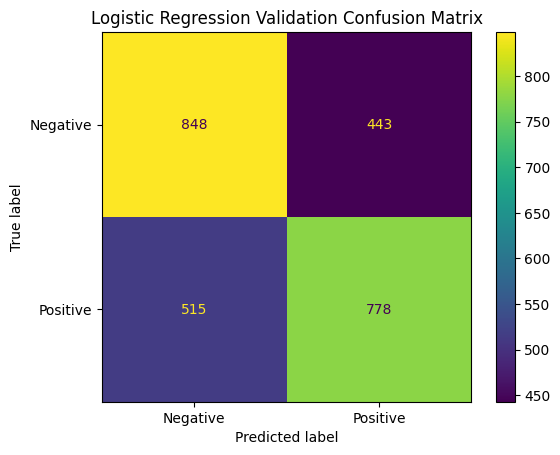

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("Logistic Regression Validation Confusion Matrix")
plt.show()

The confusion matrix shows that logistic regression is actually predicting both positive and negative cases, unlike the baseline. It correctly classified 848 negative exams and 778 positive exams, but it also had 443 false positives and 515 false negatives. This means the model learned some useful signal from the ECG features, but it still missed a good number of positive cases, so we needed to compare it with stronger models like KNN and Random Forest.

## ROC curve

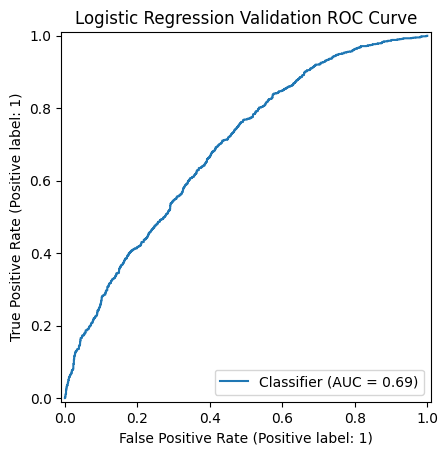

In [14]:
RocCurveDisplay.from_predictions(y_val, best_prob)

plt.title("Logistic Regression Validation ROC Curve")
plt.show()

The ROC curve shows that logistic regression performs better than guessing, with a validation ROC-AUC of about **0.69**. This means the model can separate Chagas-positive and Chagas-negative exams somewhat, but not strongly.

## Coefficients

I also checked the logistic regression coefficients because this model is easier to interpret than something like a random forest. Since the features were already scaled, the larger coefficient values show which features affected the model more.

In [15]:
weights, bias = best_model.layers[0].get_weights()

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": weights.ravel()
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient,abs_coefficient
13,ST_segment_std,0.399341,0.399341
12,ST_segment_mean,0.393474,0.393474
10,QT_interval_mean,-0.338684,0.338684
6,PR_segment_mean,0.326663,0.326663
0,age,0.316923,0.316923
8,QRS_duration_mean,0.306431,0.306431
16,HRV_RMSSD,0.243910,0.243910
17,HRV_pNN50,-0.186467,0.186467
11,QT_interval_std,-0.140262,0.140262
14,HRV_MeanNN,0.138142,0.138142


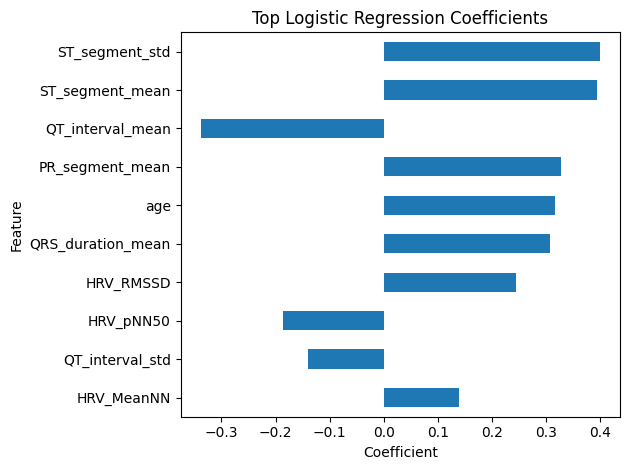

In [16]:
coef_df.head(10).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The model relied most on ST segment, QT interval, PR segment, age, QRS duration, and HRV features. Positive coefficients pushed predictions toward Chagas-positive, while negative coefficients pushed predictions toward Chagas-negative. These coefficients do not prove causation, but they help show which ECG measurements the model used most.

## Saved results

I saved the metric table and the coefficient table so we can use them later in the final model comparison and report.

In [17]:
results_dir = Path("model_results")
results_dir.mkdir(exist_ok=True)

results_df.to_csv(results_dir / "rohan_logistic_regression_results.csv", index=False)
coef_df.to_csv(results_dir / "rohan_logistic_regression_coefficients.csv", index=False)

print("Saved results to model_results/")

Saved results to model_results/


## Conclusion

The TensorFlow logistic regression model performed better than the baseline, so it showed that the ECG features do contain some useful signal. The best model used **C = 0.1** and had validation accuracy of **0.629**, F1-score of **0.619**, recall of **0.602**, and ROC-AUC of **0.692**.

This was a solid improvement over the baseline, especially because the baseline missed every positive case. However, the performance was still only moderate. The model caught about 60% of the positive Chagas exams, but it still missed a decent number of positives.

Overall, logistic regression was useful because it was simple and easy to interpret, but it was not strong enough to be our final model. These results helped show why we needed to compare it with stronger models like KNN and Random Forest.